In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset/Fake_dev.csv
/kaggle/input/dataset/Fake_train.csv
/kaggle/input/dataset/Fake_test_with_labels.csv
/kaggle/input/dataset/Fake_test_without_labels.csv
/kaggle/input/llm-prediction/predictions (1).csv


In [2]:
df_train1 = pd.read_csv('/kaggle/input/dataset/Fake_train.csv')
df_train2 = pd.read_csv('/kaggle/input/dataset/Fake_dev.csv')
df_test = pd.read_csv('/kaggle/input/dataset/Fake_test_without_labels.csv')
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')

In [3]:
df_train = pd.concat([df_train1, df_train2], ignore_index=True)
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['label'])

df_train = df_train.drop_duplicates()
df_val = df_val.drop_duplicates()

In [4]:
import emoji
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')
df_train['text'] = df_train['text'].apply(remove_emoji)
df_val['text'] = df_val['text'].apply(remove_emoji)
df_train.sample(10)

,text,label
2066,"Ne okke manappoorvam cheythathu thanne aanu, i...",Fake
2948,ശരിക്കും ഇവർ കോമാളികളാണോ അതോ കോമാളികളായിട്ട് അ...,original
244,Russia yil like ethi,Fake
355,<b>ചൈന വൈറസിനെ തുരത്തുമെന്ന് ഇത്ര ഉറപ്പിച്ചു പ...,Fake
1569,Naannakkedu.,original
3152,അവഹേളിക്കരുത് നിങ്ങൾ പറയുന്നത്.തെറ്റാണ്.IMA യെ...,Fake
3494,വ്യക്തി പൂജ പാടില്ലെന്ന് പറയുകയും ചെയ്യും എന്ന...,original
3709,"ലെ പ്രവാസികൾ :ഞങ്ങളിനി നാട്ടിലോട്ടില്ല, ഇവിടെ ...",original
1231,Ellam pravasikkal karannam pottanmaraya,original
3085,നാട്ടുകാരെ ഓടിവരണെ പ്രവാസികൾ കൊറോണ പരത്തുന്നേ<...,original


In [5]:
import re  
def remove_html(text):
    return re.sub(r'<[^>]*>','',text) 
df_train['text'] = df_train['text'].apply(remove_html)
df_val['text'] = df_val['text'].apply(remove_html)
df_train.sample(10)

,text,label
2901,ഈ പറഞ്ഞ സ്ഥലത്തെല്ലാം ഇനി മരിക്കാൻ ആളില്ലാതായി.,Fake
3228,Chetta chettande navu ponnavatte,Fake
42,e pennugalk vera valla panikum poikoode,original
346,"Third world war belongs to corona matter, wait...",Fake
3534,Jesus said believe in me you will be safe unde...,Fake
3510,ആർക്കുവേണ്ടി,original
2550,ഈ വാർത്തയിൽ ഇദ്ദേഹം ഔർ രാഷ്ട്രീയം പറയുന്നുണ്ട്...,Fake
2564,America ku vachathu Europe nu kondu.,Fake
1802,Corona is fake?,Fake
3241,ചൈനക്കാർ ലോക ശക്തിയാകാൻ കാണിച്ച പരിപാടി. അതോണ്...,Fake


In [6]:
from sklearn.preprocessing import LabelEncoder 
def encode_labels(labels):
    le = LabelEncoder()
    return le.fit_transform(labels) 
df_train['label'] = encode_labels(df_train['label'])#Fake-0
df_val['label'] = encode_labels(df_val['label']) 

In [7]:
import wandb
wandb.login(key='WANDB_API_KEY')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: minhazulkabir (minhazulkabir-none). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [9]:
!pip install --upgrade huggingface_hub
!pip install --upgrade transformers peft accelerate datasets evaluate
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 12.4 MB/s eta 0:00:0000:01
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.24.7
    Uninstalling huggingface-hub-0.24.7:
      Successfully uninstalled huggingface-hub-0.24.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 91.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 86.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: accelerate
    Found existing install

In [10]:
import os
from huggingface_hub import login

# login(token="READ_TOKEN") #read_token
login(token="WRITE_TOKEN") #write_token
#mine
#login(token = "KAGGLE_TOKEN")

In [11]:
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoTokenizer
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    DataCollatorWithPadding
)
from torch.optim.lr_scheduler import ReduceLROnPlateau
from peft import LoraConfig, get_peft_model
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import get_cosine_schedule_with_warmup

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_val)


In [12]:
# Initialize tokenizer with proper padding setup
#MODEL = "sarvamai/sarvam-1"
#MODEL = "CoRover/BharatGPT-3B-Indic"
#MODEL = "google/gemma-2-2b"
#MODEL = "meta-llama/Llama-3.2-3B"
#MODEL = "Qwen/Qwen2.5-3B" OFM
#MODEL = "nickmalhotra/ProjectIndus"
#MODEL = "VishnuPJ/MalayaLLM_7B_Base" OFM
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token  # Use EOS token as PAD token
tokenizer.padding_side = 'right'

# Preprocessing function
def preprocess_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors=None
    )
    tokenized['label'] = examples['label']
    return tokenized

# Encode datasets
encoded_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)
encoded_test = test_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=test_dataset.column_names
)

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Map:   0%|          | 0/3187 [00:00<?, ? examples/s]

Map:   0%|          | 0/812 [00:00<?, ? examples/s]

In [13]:
# Set up model
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32
)

# Initialize model with proper padding token configuration
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    num_labels=2,
    torch_dtype=torch.float32,
    pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id to eos_token_id
)
#print(model)

config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at nickmalhotra/ProjectIndus and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
# Configure model padding token
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False  # Disable cache to prevent memory issues

# Configure LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    #target_modules=["attn.c_attn", "attn.c_proj"],
    lora_dropout=0.15,
    bias="none",
    task_type="SEQ_CLS"
)

model = get_peft_model(model, lora_config)


In [15]:
# Prepare data loaders

from torch.utils.data import WeightedRandomSampler

def get_balanced_sampler(dataset):
    labels = [example['label'] for example in dataset]
    class_counts = np.bincount(labels)
    weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = weights[labels]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

# Use in DataLoader
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_dataloader = DataLoader(
    encoded_train,
    sampler=get_balanced_sampler(encoded_train),
    batch_size=16,
    collate_fn=data_collator
)

eval_dataloader = DataLoader(
    encoded_test,
    batch_size=16,
    collate_fn=data_collator
)

# Training configuration
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
    eps=1e-8,
    betas=(0.9, 0.999)
)

# Add learning rate scheduler
num_epochs = 5
num_training_steps = num_epochs * len(train_dataloader)

# Calculate warmup steps (10% of total steps)
# num_warmup_steps = int(0.1 * num_training_steps)

# Create scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)


In [16]:
import os
import torch
import json
from huggingface_hub import login, upload_folder
from sklearn.metrics import f1_score
from tqdm import tqdm

# Define training loop with model saving and uploading

def train_and_save_best_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    progress_bar = tqdm(range(num_training_steps))

    best_f1 = -1
    best_model_dir = './best_model'

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, batch in enumerate(train_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss

            if torch.isnan(loss).any():
                print(f"NaN loss detected at batch {batch_idx}!")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()
            progress_bar.update(1)

            if (batch_idx + 1) % 100 == 0:
                avg_loss = total_loss / (batch_idx + 1)
                print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Average Loss: {avg_loss:.4f}")

        # Evaluation
        model.eval()
        eval_loss = 0
        predictions = []
        references = []

        with torch.no_grad():
            for batch in eval_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)

                eval_loss += outputs.loss.item()
                pred_labels = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
                true_labels = batch["labels"].cpu().numpy()

                predictions.extend(pred_labels)
                references.extend(true_labels)

        eval_loss /= len(eval_dataloader)

        # Calculate F1 score
        f1 = f1_score(references, predictions, average='macro')  # 'binary' for binary classification
        print(f"Epoch {epoch+1}: Evaluation F1 Score: {f1:.4f}")

        # Save best model based on F1 score
        if f1 > best_f1:
            best_f1 = f1
            os.makedirs(best_model_dir, exist_ok=True)

            # Save model, tokenizer, and hyperparameters
            model.save_pretrained(best_model_dir)
            tokenizer.save_pretrained(best_model_dir)

            # Save hyperparameters
            hyperparameters = {
                'model_name': 'sarvamai/sarvam-1',
                'learning_rate': 1e-4,
                'num_train_epochs': num_epochs,
                'batch_size': 16
            }
            with open(os.path.join(best_model_dir, 'hyperparameters.json'), 'w') as f:
                json.dump(hyperparameters, f)

            print(f"Best model saved with F1 score: {f1:.4f}")

    return best_model_dir

# After training completes, upload the best model to Hugging Face Hub (Kaggle Hub equivalent)
def upload_to_kagglehub(best_model_dir):
    repo_name = "your_username/your_model_repo_name"  # Ensure the repo name is correct

    # Log in to Kaggle Hub (Hugging Face Hub)
    login(token="your_hugging_face_token")

    # Upload the best model folder to Hugging Face Hub
    upload_folder(
        folder_path=best_model_dir,
        path_in_repo=".",  # Place everything in the root directory of the repository
        repo_id=repo_name
    )

    print(f"Model, tokenizer, and hyperparameters have been successfully uploaded to Hugging Face Hub: {repo_name}")

# Example Usage
best_model_dir = train_and_save_best_model()
#upload_to_kagglehub(best_model_dir)


 10%|█         | 100/1000 [04:45<42:41,  2.85s/it]

Epoch 1, Batch 100, Average Loss: 1.1638


 20%|██        | 200/1000 [09:28<29:01,  2.18s/it]

Epoch 1, Batch 200, Average Loss: 0.8689
Epoch 1: Evaluation F1 Score: 0.6723
Best model saved with F1 score: 0.6723


 30%|███       | 300/1000 [15:20<33:09,  2.84s/it]  

...

Epoch 5, Batch 100, Average Loss: 0.1120


100%|██████████| 1000/1000 [51:45<00:00,  2.18s/it]

Epoch 5, Batch 200, Average Loss: 0.1063


100%|██████████| 1000/1000 [52:52<00:00,  3.17s/it]

Epoch 5: Evaluation F1 Score: 0.7999


In [16]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import tqdm

# Training loop
device = "cuda" if torch.cuda.is_available() else "cpu"
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        if torch.isnan(loss).any():
            print(f"NaN loss detected at batch {batch_idx}!")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.update(1)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Average Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    eval_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            eval_loss += outputs.loss.item()
            pred_labels = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            true_labels = batch["labels"].cpu().numpy()

            predictions.extend(pred_labels)
            references.extend(true_labels)

    eval_loss /= len(eval_dataloader)

    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == np.array(references))

    # Calculate F1 score
    f1 = f1_score(references, predictions, average='macro')  # 'binary' for binary classification

    # Scheduler step
    scheduler.step(eval_loss)

    # Print metrics
    print(f"\nEpoch {epoch+1}:")
    print(f"Average Training Loss: {total_loss/len(train_dataloader):.4f}")
    print(f"Evaluation Loss: {eval_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")


 10%|█         | 100/1000 [04:45<42:41,  2.85s/it]

Epoch 1, Batch 100, Average Loss: 0.8610


 20%|██        | 200/1000 [09:27<29:03,  2.18s/it]

Epoch 1, Batch 200, Average Loss: 0.6992

Epoch 1:
Average Training Loss: 0.6992
Evaluation Loss: 0.5269
Accuracy: 0.7328
F1 Score: 0.7299


 30%|███       | 300/1000 [15:19<33:09,  2.84s/it]  

...

Epoch 4, Batch 200, Average Loss: 0.1626

Epoch 4:
Average Training Loss: 0.1626
Evaluation Loss: 0.6191
Accuracy: 0.8325
F1 Score: 0.8322


 90%|█████████ | 900/1000 [46:59<04:44,  2.85s/it]  

Epoch 5, Batch 100, Average Loss: 0.1063


100%|██████████| 1000/1000 [51:41<00:00,  2.18s/it]

Epoch 5, Batch 200, Average Loss: 0.1016

Epoch 5:
Average Training Loss: 0.1016
Evaluation Loss: 0.7349
Accuracy: 0.8091
F1 Score: 0.8091


In [17]:
import pandas as pd
import torch
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

max_len = 128

def make_test():
    df_test['text'] = df_test['text'].apply(remove_emoji)  # Removing emojis
    df_test['text'] = df_test['text'].apply(remove_html)  # Removing HTML tags

    # Tokenize the test data
    test_encodings = tokenizer(df_test['text'].tolist(), truncation=True, padding=True, max_length=max_len, return_tensors="pt")

    # Create a DataLoader for batch processing
    test_dataset = torch.utils.data.TensorDataset(
        test_encodings['input_ids'],
        test_encodings['attention_mask']
    )
    
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    # Make predictions using the model
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred_labels = torch.argmax(logits, dim=-1).cpu().numpy()

            predictions.extend(pred_labels)

    # Store predictions in the dataframe
    df_test['Labels'] = predictions

    # Save to CSV
    df_test.to_csv('predictions.csv', index=False)

make_test()



100%|██████████| 64/64 [01:24<00:00,  1.32s/it]


In [18]:
x=pd.read_csv('/kaggle/working/predictions.csv')
x

,Id,text,Labels
0,Fake_01,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,0
1,Fake_02,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,0
2,Fake_03,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,0
3,Fake_04,Shame for entire Woman&#39;s of Kerala,1
4,Fake_05,135 code janaghal andhu wide business cheythal...,0
...,...,...,...
1014,Fake_1015,Correct ...China cheitha ...weapon spread ing ...,0
1015,Fake_1016,ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...,0
1016,Fake_1017,Mask illa aarkum,1
1017,Fake_1018,ഇയാളെ കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!,0


In [20]:
x['Labels'].value_counts()

Labels
1    528
0    491
Name: count, dtype: int64

In [21]:
def Testing():
    import pandas as pd
    from sklearn.metrics import f1_score
    
    predicted_df = pd.read_csv("/kaggle/working/predictions.csv")
    
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    #  'Fake' is 0 and 'original' is 1
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)
    
    # Ensure that both the real and predicted labels are numpy arrays or lists
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    
    print(f"F1 Score: {f1:.4f}")
Testing()#79

F1 Score: 0.8390


**Sarvamai**

F1 Score: 0.8390

Classification Report:
              precision    recall  f1-score   support

        Fake       0.85      0.82      0.84       507
    Original       0.83      0.86      0.84       512

    accuracy                           0.84      1019
   macro avg       0.84      0.84      0.84      1019
weighted avg       0.84      0.84      0.84      1019


Confusion Matrix:


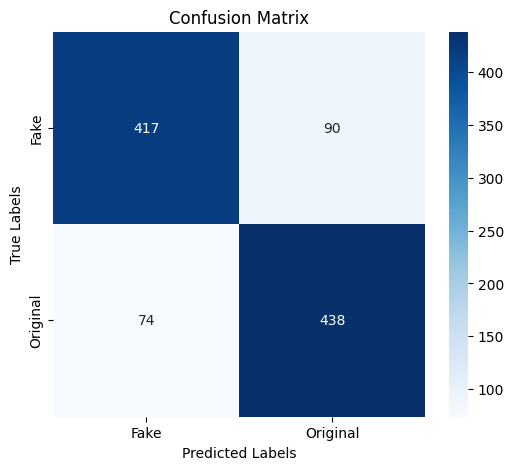

In [3]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def Testing():
    predicted_df = pd.read_csv('/kaggle/input/llm-prediction/predictions (1).csv')  

    # Assuming 'label' is the real labels and 'Labels' are the predicted labels
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)

    # Ensure that both real and predicted labels are numpy arrays
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    # Calculate F1 Score (macro average for multi-class, binary works fine too)
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Generate the Classification Report
    print("\nClassification Report:")
    print(classification_report(real_labels, predicted_labels, target_names=['Fake', 'Original']))
    
    # Generate the Confusion Matrix
    print("\nConfusion Matrix:")
    cm=confusion_matrix(real_labels,predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Testing()


In [22]:
def save_best_model():
    import json
    from transformers import BertForSequenceClassification, BertTokenizer
    import os
    
    # Define your hyperparameters
    hyperparameters = {
        'model_name': 'sarvamai/sarvam-1',
        'T_sz': 0.2,
        'mx_len': 128,
        'b_sz': 16,
        'learning_rate': 1e-4,
        'num_train_epochs': 5,
        'batch_size': 16,
        'gradient_accumulation_steps': 1
    }
    
    # Create a directory to save the model and other artifacts
    output_dir = './best_model'
    os.makedirs(output_dir, exist_ok=True)
    
    # Save hyperparameters to a JSON file
    with open(os.path.join(output_dir, 'hyperparameters.json'), 'w') as f:
        json.dump(hyperparameters, f)
    
    # Save the model and tokenizer
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    print(f"Model, tokenizer, and hyperparameters saved in {output_dir}")
#save_best_model()

Model, tokenizer, and hyperparameters saved in ./best_model


In [25]:
# After training completes, upload the best model to Hugging Face Hub (Kaggle Hub equivalent)
from huggingface_hub import upload_folder
def upload_to_kagglehub(best_model_dir):
    repo_name = "R1FA7/Fake-sarvamllm"  # Ensure the repo name is correct

    # Upload the best model folder to Hugging Face Hub
    upload_folder(
        folder_path=best_model_dir,
        path_in_repo=".",  # Place everything in the root directory of the repository
        repo_id=repo_name
    )

    print(f"Model, tokenizer, and hyperparameters have been successfully uploaded to Hugging Face Hub: {repo_name}")

#upload_to_kagglehub("/kaggle/working/best_model")

tokenizer.model:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

Model, tokenizer, and hyperparameters have been successfully uploaded to Hugging Face Hub: R1FA7/Fake-sarvamllm


**google/gemma-2-2b**

In [20]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import tqdm

# Training loop
device = "cuda" if torch.cuda.is_available() else "cpu"
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        if torch.isnan(loss).any():
            print(f"NaN loss detected at batch {batch_idx}!")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.update(1)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Average Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    eval_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            eval_loss += outputs.loss.item()
            pred_labels = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            true_labels = batch["labels"].cpu().numpy()

            predictions.extend(pred_labels)
            references.extend(true_labels)

    eval_loss /= len(eval_dataloader)

    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == np.array(references))

    # Calculate F1 score
    f1 = f1_score(references, predictions, average='macro')  # 'binary' for binary classification

    # Scheduler step
    scheduler.step(eval_loss)

    # Print metrics
    print(f"\nEpoch {epoch+1}:")
    print(f"Average Training Loss: {total_loss/len(train_dataloader):.4f}")
    print(f"Evaluation Loss: {eval_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")


 10%|█         | 100/1000 [04:19<38:51,  2.59s/it]

Epoch 1, Batch 100, Average Loss: 1.3325


 20%|██        | 200/1000 [08:36<26:26,  1.98s/it]

Epoch 1, Batch 200, Average Loss: 0.9656

Epoch 1:
Average Training Loss: 0.9656
Evaluation Loss: 0.6388
Accuracy: 0.7291
F1 Score: 0.7273


 30%|███       | 300/1000 [13:57<30:07,  2.58s/it]  

...

Epoch 4, Batch 200, Average Loss: 0.1587

Epoch 4:
Average Training Loss: 0.1587
Evaluation Loss: 0.8848
Accuracy: 0.7808
F1 Score: 0.7762


 90%|█████████ | 900/1000 [42:46<04:18,  2.58s/it]  

Epoch 5, Batch 100, Average Loss: 0.0880


100%|██████████| 1000/1000 [47:02<00:00,  1.98s/it]

Epoch 5, Batch 200, Average Loss: 0.0897

Epoch 5:
Average Training Loss: 0.0897
Evaluation Loss: 0.6801
Accuracy: 0.8251
F1 Score: 0.8250


In [21]:
import pandas as pd
import torch
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

max_len = 128

def make_test():
    # Assuming df_test is the dataframe you want to make predictions on
    # df_test = pd.read_csv('/path/to/your/test_data.csv')  # Path to your test file
    df_test['text'] = df_test['text'].apply(remove_emoji)  # Removing emojis
    df_test['text'] = df_test['text'].apply(remove_html)  # Removing HTML tags

    # Tokenize the test data
    test_encodings = tokenizer(df_test['text'].tolist(), truncation=True, padding=True, max_length=max_len, return_tensors="pt")

    # Create a DataLoader for batch processing
    test_dataset = torch.utils.data.TensorDataset(
        test_encodings['input_ids'],
        test_encodings['attention_mask']
    )
    
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    # Make predictions using the model
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred_labels = torch.argmax(logits, dim=-1).cpu().numpy()

            predictions.extend(pred_labels)

    # Store predictions in the dataframe
    df_test['Labels'] = predictions

    # Save to CSV
    df_test.to_csv('predictions.csv', index=False)

make_test()



100%|██████████| 64/64 [01:18<00:00,  1.22s/it]


In [23]:
x=pd.read_csv('/kaggle/working/predictions.csv')
x

,Id,text,Labels
0,Fake_01,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,0
1,Fake_02,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,0
2,Fake_03,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,1
3,Fake_04,Shame for entire Woman&#39;s of Kerala,1
4,Fake_05,135 code janaghal andhu wide business cheythal...,0
...,...,...,...
1014,Fake_1015,Correct ...China cheitha ...weapon spread ing ...,0
1015,Fake_1016,ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...,0
1016,Fake_1017,Mask illa aarkum,1
1017,Fake_1018,ഇയാളെ കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!,0


In [24]:
real_df

,text,label
0,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,Fake
1,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,Fake
2,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,Fake
3,Shame for entire Woman&#39;s of Kerala,original
4,135 code janaghal andhu wide business cheythal...,Fake
...,...,...
1014,Correct ...China cheitha ...weapon spread ing ...,Fake
1015,ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...,Fake
1016,Mask illa aarkum😏😏,original
1017,ഇയാളെ കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!,Fake


F1 Score: 0.8263

Classification Report:
              precision    recall  f1-score   support

        Fake       0.81      0.84      0.83       507
    Original       0.84      0.81      0.82       512

    accuracy                           0.83      1019
   macro avg       0.83      0.83      0.83      1019
weighted avg       0.83      0.83      0.83      1019


Confusion Matrix:


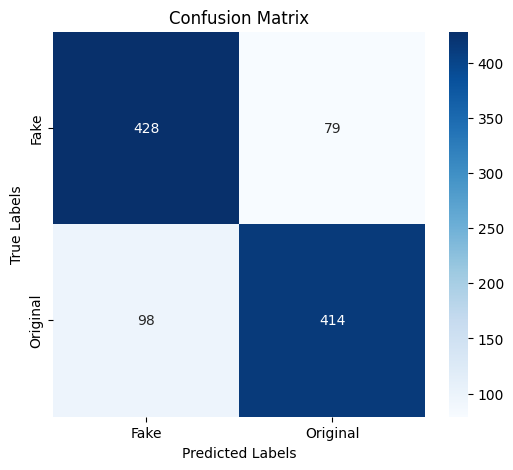

In [26]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def Testing():
    predicted_df = pd.read_csv("/kaggle/working/predictions.csv")  

    # Assuming 'label' is the real labels and 'Labels' are the predicted labels
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)

    # Ensure that both real and predicted labels are numpy arrays
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    # Calculate F1 Score (macro average for multi-class, binary works fine too)
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Generate the Classification Report
    print("\nClassification Report:")
    print(classification_report(real_labels, predicted_labels, target_names=['Fake', 'Original']))
    
    # Generate the Confusion Matrix
    print("\nConfusion Matrix:")
    cm=confusion_matrix(real_labels,predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Testing()


**meta-llama/Llama-3.2-3B**

In [16]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import tqdm

# Training loop
device = "cuda" if torch.cuda.is_available() else "cpu"
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        if torch.isnan(loss).any():
            print(f"NaN loss detected at batch {batch_idx}!")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.update(1)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Average Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    eval_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            eval_loss += outputs.loss.item()
            pred_labels = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            true_labels = batch["labels"].cpu().numpy()

            predictions.extend(pred_labels)
            references.extend(true_labels)

    eval_loss /= len(eval_dataloader)

    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == np.array(references))

    # Calculate F1 score
    f1 = f1_score(references, predictions, average='macro')  # 'binary' for binary classification

    # Scheduler step
    scheduler.step(eval_loss)

    # Print metrics
    print(f"\nEpoch {epoch+1}:")
    print(f"Average Training Loss: {total_loss/len(train_dataloader):.4f}")
    print(f"Evaluation Loss: {eval_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")


 10%|█         | 100/1000 [05:53<52:53,  3.53s/it]

Epoch 1, Batch 100, Average Loss: 0.7467


 20%|██        | 200/1000 [11:42<35:58,  2.70s/it]

Epoch 1, Batch 200, Average Loss: 0.6591

Epoch 1:
Average Training Loss: 0.6591
Evaluation Loss: 0.5709
Accuracy: 0.7106
F1 Score: 0.7106


 30%|███       | 300/1000 [18:59<40:59,  3.51s/it]  

...

Epoch 4, Batch 200, Average Loss: 0.1464

Epoch 4:
Average Training Loss: 0.1464
Evaluation Loss: 0.6918
Accuracy: 0.8091
F1 Score: 0.8090


 90%|█████████ | 900/1000 [58:16<05:50,  3.51s/it]  

Epoch 5, Batch 100, Average Loss: 0.1309


100%|██████████| 1000/1000 [1:04:05<00:00,  2.69s/it]

Epoch 5, Batch 200, Average Loss: 0.1142

Epoch 5:
Average Training Loss: 0.1142
Evaluation Loss: 0.7939
Accuracy: 0.8276
F1 Score: 0.8268


In [17]:
import pandas as pd
import torch
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

max_len = 128

def make_test():
    # Assuming df_test is the dataframe you want to make predictions on
    # df_test = pd.read_csv('/path/to/your/test_data.csv')  # Path to your test file
    df_test['text'] = df_test['text'].apply(remove_emoji)  # Removing emojis
    df_test['text'] = df_test['text'].apply(remove_html)  # Removing HTML tags

    # Tokenize the test data
    test_encodings = tokenizer(df_test['text'].tolist(), truncation=True, padding=True, max_length=max_len, return_tensors="pt")

    # Create a DataLoader for batch processing
    test_dataset = torch.utils.data.TensorDataset(
        test_encodings['input_ids'],
        test_encodings['attention_mask']
    )
    
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    # Make predictions using the model
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred_labels = torch.argmax(logits, dim=-1).cpu().numpy()

            predictions.extend(pred_labels)

    # Store predictions in the dataframe
    df_test['Labels'] = predictions

    # Save to CSV
    df_test.to_csv('predictions.csv', index=False)

make_test()



100%|██████████| 64/64 [01:48<00:00,  1.69s/it]


F1 Score: 0.8431

Classification Report:
              precision    recall  f1-score   support

        Fake       0.90      0.78      0.83       507
    Original       0.80      0.91      0.85       512

    accuracy                           0.84      1019
   macro avg       0.85      0.84      0.84      1019
weighted avg       0.85      0.84      0.84      1019


Confusion Matrix:


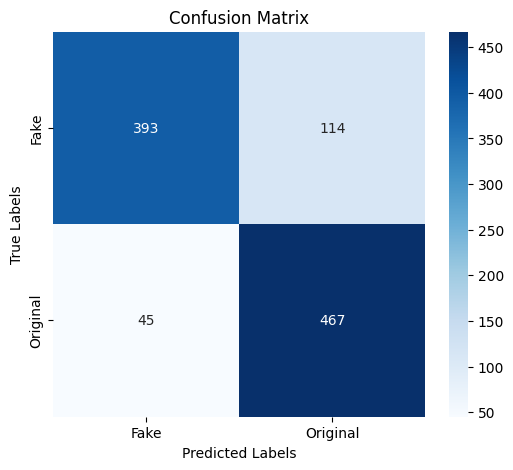

In [18]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def Testing():
    predicted_df = pd.read_csv("/kaggle/working/predictions.csv")  

    # Assuming 'label' is the real labels and 'Labels' are the predicted labels
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)

    # Ensure that both real and predicted labels are numpy arrays
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    # Calculate F1 Score (macro average for multi-class, binary works fine too)
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Generate the Classification Report
    print("\nClassification Report:")
    print(classification_report(real_labels, predicted_labels, target_names=['Fake', 'Original']))
    
    # Generate the Confusion Matrix
    print("\nConfusion Matrix:")
    cm=confusion_matrix(real_labels,predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Testing()

**nickmalhotra/ProjectIndus**

In [16]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import tqdm

# Training loop
device = "cuda" if torch.cuda.is_available() else "cpu"
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        if torch.isnan(loss).any():
            print(f"NaN loss detected at batch {batch_idx}!")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.update(1)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Average Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    eval_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            eval_loss += outputs.loss.item()
            pred_labels = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            true_labels = batch["labels"].cpu().numpy()

            predictions.extend(pred_labels)
            references.extend(true_labels)

    eval_loss /= len(eval_dataloader)

    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == np.array(references))

    # Calculate F1 score
    f1 = f1_score(references, predictions, average='macro')  # 'binary' for binary classification

    # Scheduler step
    scheduler.step(eval_loss)

    # Print metrics
    print(f"\nEpoch {epoch+1}:")
    print(f"Average Training Loss: {total_loss/len(train_dataloader):.4f}")
    print(f"Evaluation Loss: {eval_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")


 10%|█         | 100/1000 [02:38<23:41,  1.58s/it]

Epoch 1, Batch 100, Average Loss: 0.7235


 20%|██        | 200/1000 [05:14<16:08,  1.21s/it]

Epoch 1, Batch 200, Average Loss: 0.7072

Epoch 1:
Average Training Loss: 0.7072
Evaluation Loss: 0.7846
Accuracy: 0.5406
F1 Score: 0.4663


 30%|███       | 300/1000 [08:29<18:11,  1.56s/it]  

...

Epoch 4, Batch 200, Average Loss: 0.6051

Epoch 4:
Average Training Loss: 0.6051
Evaluation Loss: 0.6834
Accuracy: 0.6379
F1 Score: 0.6378


 90%|█████████ | 900/1000 [25:58<02:36,  1.57s/it]

Epoch 5, Batch 100, Average Loss: 0.5635


100%|██████████| 1000/1000 [28:33<00:00,  1.19s/it]

Epoch 5, Batch 200, Average Loss: 0.5356

Epoch 5:
Average Training Loss: 0.5356
Evaluation Loss: 0.6531
Accuracy: 0.6576
F1 Score: 0.6532


In [17]:
import pandas as pd
import torch
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

max_len = 128

def make_test():
    # Assuming df_test is the dataframe you want to make predictions on
    # df_test = pd.read_csv('/path/to/your/test_data.csv')  # Path to your test file
    df_test['text'] = df_test['text'].apply(remove_emoji)  # Removing emojis
    df_test['text'] = df_test['text'].apply(remove_html)  # Removing HTML tags

    # Tokenize the test data
    test_encodings = tokenizer(df_test['text'].tolist(), truncation=True, padding=True, max_length=max_len, return_tensors="pt")

    # Create a DataLoader for batch processing
    test_dataset = torch.utils.data.TensorDataset(
        test_encodings['input_ids'],
        test_encodings['attention_mask']
    )
    
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    # Make predictions using the model
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred_labels = torch.argmax(logits, dim=-1).cpu().numpy()

            predictions.extend(pred_labels)

    # Store predictions in the dataframe
    df_test['Labels'] = predictions

    # Save to CSV
    df_test.to_csv('predictions.csv', index=False)

make_test()



100%|██████████| 64/64 [00:48<00:00,  1.32it/s]


F1 Score: 0.5986

Classification Report:
              precision    recall  f1-score   support

        Fake       0.59      0.62      0.60       507
    Original       0.60      0.58      0.59       512

    accuracy                           0.60      1019
   macro avg       0.60      0.60      0.60      1019
weighted avg       0.60      0.60      0.60      1019


Confusion Matrix:


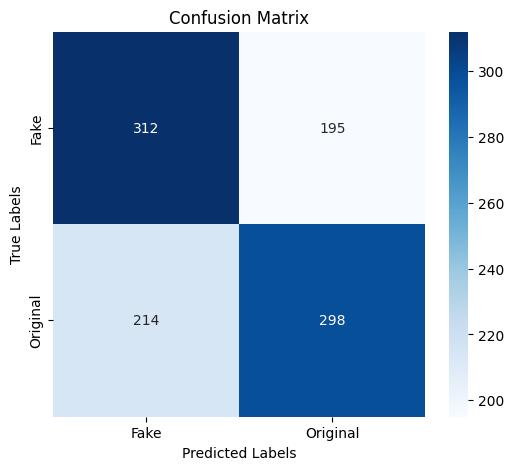

In [18]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def Testing():
    predicted_df = pd.read_csv("/kaggle/working/predictions.csv")  

    # Assuming 'label' is the real labels and 'Labels' are the predicted labels
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)

    # Ensure that both real and predicted labels are numpy arrays
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    # Calculate F1 Score (macro average for multi-class, binary works fine too)
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Generate the Classification Report
    print("\nClassification Report:")
    print(classification_report(real_labels, predicted_labels, target_names=['Fake', 'Original']))
    
    # Generate the Confusion Matrix
    print("\nConfusion Matrix:")
    cm=confusion_matrix(real_labels,predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Testing()


**Load and Predict**

In [5]:
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM, AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import emoji
import re
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Function to remove emojis and HTML tags
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

def remove_html(text):
    return re.sub(r'<[^>]*>', '', text)

# Function to get predictions for the model
def get_predictions_for_model(real_df, model, tokenizer, device, max_len=128):
    real_df['text'] = real_df['text'].apply(remove_emoji)  # Removing emojis
    real_df['text'] = real_df['text'].apply(remove_html)  # Removing HTML tags

    # Tokenize the test data
    test_encodings = tokenizer(
        real_df['text'].tolist(),
        truncation=True,
        padding=True,
        max_length=max_len,
        return_tensors="pt"
    )

    # Create a DataLoader for batch processing
    test_dataset = TensorDataset(
        test_encodings['input_ids'],
        test_encodings['attention_mask']
    )
    
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    # Make predictions using the model
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred_labels = torch.argmax(logits, dim=-1).cpu().numpy()

            predictions.extend(pred_labels)

    # Store predictions in the dataframe
    real_df['Labels'] = predictions
    output_dir = '/kaggle/working'  # Use the root output directory

    # Save predictions to a CSV file
    model_prediction_file = os.path.join(output_dir, "predictions_fake_sarvamllm.csv")
    real_df[['text', 'Labels']].to_csv(model_prediction_file, index=False)

    return real_df, predictions

# Function to calculate F1 score, classification report, and confusion matrix
def calculate_metrics(real_df, predicted_labels):
    # Map the labels to 0 and 1 (Fake -> 0, Original -> 1)
    real_labels = real_df['label'].map({'Fake': 0, 'original': 1}).to_numpy()

    # F1 Score
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Classification Report
    print("Classification Report:")
    report = classification_report(real_labels, predicted_labels, target_names=['Fake', 'original'])
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(real_labels, predicted_labels)
    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'original'], yticklabels=['Fake', 'original'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Main function to handle predictions
def prediction():
    # Load the real dataset with labels
    real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')
    
    
    # Define the repository name of the model you uploaded
    repo = "R1FA7/Fake-sarvamllm"  # Replace with your actual model repo name
    
    # Load the model and tokenizer
    model = AutoModelForCausalLM.from_pretrained(repo)
    tokenizer = AutoTokenizer.from_pretrained(repo)

    # Set device (CUDA if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get predictions
    real_df, predicted_labels = get_predictions_for_model(real_df, model, tokenizer, device, max_len=128)
    
    # Calculate metrics
    calculate_metrics(real_df, predicted_labels)

# Run the prediction function
prediction()


OSError: R1FA7/Fake-sarvamllm does not appear to have a file named config.json. Checkout 'https://huggingface.co/R1FA7/Fake-sarvamllm/tree/main' for available files.